# Three-seed checkpoint generator evaluation

This is a **report-only** companion for the frozen VAE-v3 and conditional-diffusion checkpoints.
It reads only the bounded package under `reports/generator_checkpoint_evaluation_2026-08-10/`;
ignored checkpoints and bulk pools are not required. The CRNN is the primary evaluator and the
legacy residual CNN is a sensitivity check. Results are classifier-view evidence, not claims
about waveform quality or human-perceived realism.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'src' / 'bird_song').is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
REPORT_DIR = PROJECT_ROOT / 'reports' / 'generator_checkpoint_evaluation_2026-08-10'
assert REPORT_DIR.is_dir(), REPORT_DIR
summary = json.loads((REPORT_DIR / 'summary.json').read_text(encoding='utf-8'))
protocol = json.loads((REPORT_DIR / 'protocol.json').read_text(encoding='utf-8'))
print(summary['title'])
print('Generated arrays:', summary['generated_arrays_total'])
print('Seeds:', protocol['seeds'])
print('Primary evaluator:', protocol['primary_classifier'])

Three-seed checkpoint generator evaluation
Generated arrays: 3600
Seeds: [42, 123, 777]
Primary evaluator: crnn


In [2]:
calibration = pd.DataFrame(summary['calibration'])
display(calibration[['classifier', 'split', 'sample_count', 'accuracy', 'macro_f1', 'expected_accuracy', 'expected_macro_f1']])
assert (calibration['accuracy'] - calibration['expected_accuracy']).abs().max() < 1e-8
assert (calibration['macro_f1'] - calibration['expected_macro_f1']).abs().max() < 1e-8
display(pd.DataFrame({
    'setting': ['samples/species/seed', 'total arrays/model', 'resamples', 'resample size/species', 'copy-risk threshold'],
    'value': [protocol['samples_per_species'], protocol['total_samples_per_model'], protocol['sample_sensitive_metrics']['resamples'], protocol['sample_sensitive_metrics']['sample_size_per_species'], protocol['copy_risk']['quantile']],
}))

,classifier,split,sample_count,accuracy,macro_f1,expected_accuracy,expected_macro_f1
0,crnn,test,489,0.899796,0.901618,0.899796,0.901618
1,residual,test,489,0.903885,0.904446,0.903885,0.904446


,setting,value
0,samples/species/seed,200.00
1,total arrays/model,1800.00
2,resamples,200.00
3,resample size/species,128.00
4,copy-risk threshold,0.05


In [3]:
per_seed = pd.read_csv(REPORT_DIR / 'metrics_per_seed.csv')
aggregate = pd.read_csv(REPORT_DIR / 'metrics_aggregate.csv')
assert len(per_seed) == 36
assert set(per_seed['seed']) == set(protocol['seeds'])
assert set(per_seed['model']) == {'vae_v3', 'diffusion'}
assert summary['generated_arrays_total'] == len(protocol['seeds']) * 2 * 3 * protocol['samples_per_species']
assert len(aggregate) == 12
primary = per_seed[per_seed['classifier'] == 'crnn'].copy()
seed_table = (primary.groupby(['model', 'seed'], as_index=False)
              .agg(target_accuracy=('target_label_accuracy', 'mean'), macro_f1=('macro_f1', 'first'),
                   feature_distance=('frechet_mean', 'mean'), copy_risk=('exact_train_duplicate_count', 'first')))
display(seed_table.sort_values(['model', 'seed']).round(4))
display(aggregate[(aggregate['classifier'] == 'crnn') & (aggregate['species'] == 'American Robin')][['model', 'classifier', 'species', 'target_label_accuracy_mean', 'target_label_accuracy_std', 'target_label_accuracy_min', 'target_label_accuracy_max', 'frechet_mean_mean', 'generated_diversity_mean_mean']].round(4))

,model,seed,target_accuracy,macro_f1,feature_distance,copy_risk
0,diffusion,42,0.3450,0.1928,548.6576,0
1,diffusion,123,0.9267,0.9264,38.4757,0
2,diffusion,777,0.9317,0.9313,43.0565,0
3,vae_v3,42,0.9650,0.9649,21.2322,0
4,vae_v3,123,0.9667,0.9666,19.7870,0
5,vae_v3,777,0.9750,0.9750,26.7217,0


,model,classifier,species,target_label_accuracy_mean,target_label_accuracy_std,target_label_accuracy_min,target_label_accuracy_max,frechet_mean_mean,generated_diversity_mean_mean
0,diffusion,crnn,American Robin,0.6267,0.5427,0.000,0.945,286.0963,9.2721
6,vae_v3,crnn,American Robin,0.9950,0.0000,0.995,0.995,14.0050,8.4151


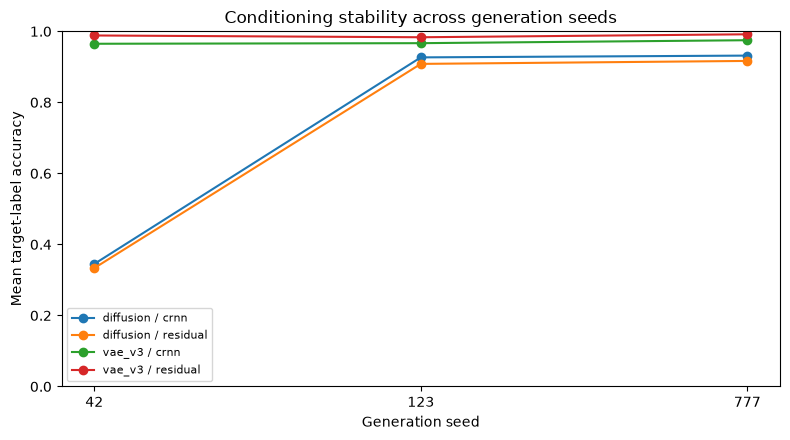

In [4]:
figure, axis = plt.subplots(figsize=(8, 4.5))
for (model, classifier), group in per_seed.groupby(['model', 'classifier']):
    values = group.groupby('seed')['target_label_accuracy'].mean()
    axis.plot(values.index.astype(str), values.values, marker='o', label=f'{model} / {classifier}')
axis.set(xlabel='Generation seed', ylabel='Mean target-label accuracy', ylim=(0, 1), title='Conditioning stability across generation seeds')
axis.legend(fontsize=8)
figure.tight_layout()
display(figure)
plt.close(figure)

,model,seed,species,copy_risk_threshold,nearest_train_min,nearest_train_median,below_threshold_fraction,exact_train_duplicate_count
0,vae_v3,42,American Robin,2.0642,1.5080,2.7648,0.160,0
1,vae_v3,42,Northern Cardinal,2.6661,0.9861,2.7617,0.465,0
2,vae_v3,42,Song Sparrow,2.4819,0.8659,2.5544,0.460,0
3,vae_v3,123,American Robin,2.0642,1.5452,2.8369,0.180,0
4,vae_v3,123,Northern Cardinal,2.6661,0.9853,2.7787,0.475,0
5,vae_v3,123,Song Sparrow,2.4819,1.0280,2.6558,0.440,0
6,vae_v3,777,American Robin,2.0642,1.5665,2.8807,0.165,0
7,vae_v3,777,Northern Cardinal,2.6661,0.9890,2.7104,0.490,0
8,vae_v3,777,Song Sparrow,2.4819,0.8876,2.6088,0.445,0
9,diffusion,42,American Robin,2.0642,18.5718,23.1455,0.000,0


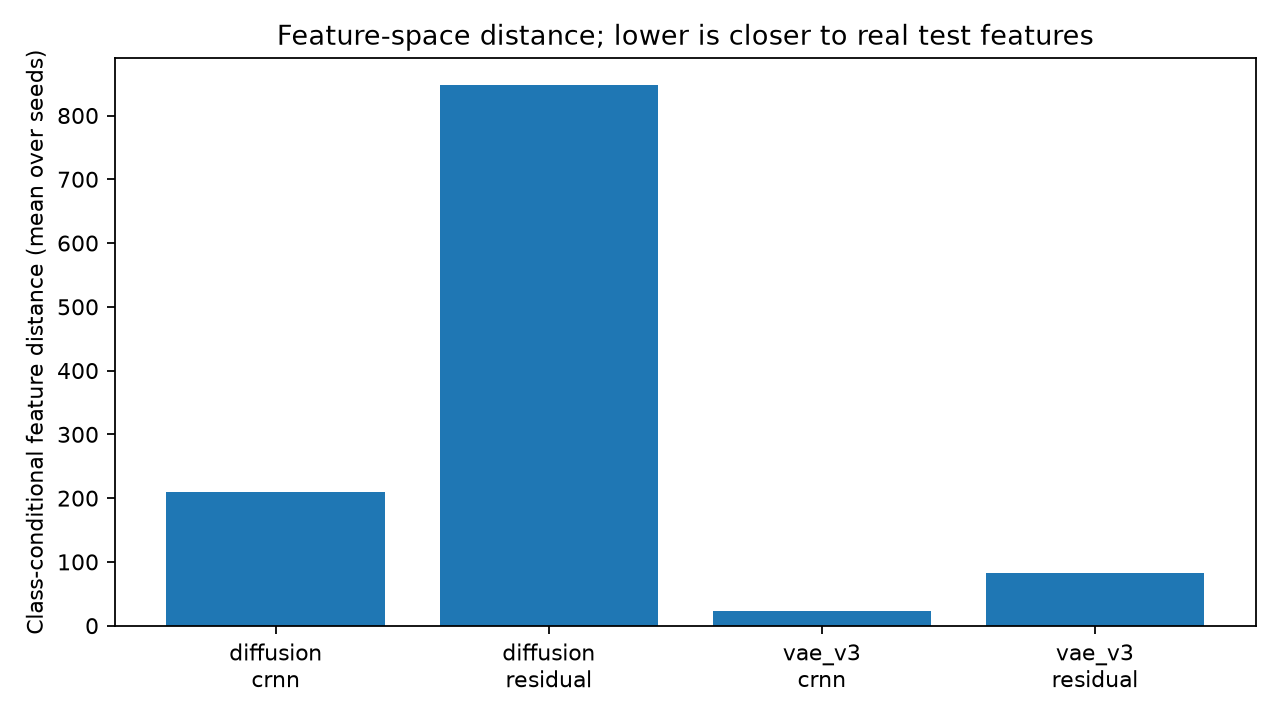

In [5]:
nearest = pd.read_csv(REPORT_DIR / 'nearest_neighbor_summary.csv')
display(nearest[nearest['classifier'] == 'crnn'][['model', 'seed', 'species', 'copy_risk_threshold', 'nearest_train_min', 'nearest_train_median', 'below_threshold_fraction', 'exact_train_duplicate_count']].round(4))
display(Image(filename=str(REPORT_DIR / 'figures' / 'feature_distance_summary.png')))

## Interpretation

The three seeds are shown individually and summarized with mean, sample standard deviation, and range;
no composite score or significance test is used. The CRNN result is primary, while residual-CNN
disagreement is reported as encoder dependence. Copy-risk thresholds come from content-safe validation
nearest-neighbor distances before generated samples are inspected. The historical seed-42 pool is
preserved; seeds 123 and 777 are inference-only additions.

These results support claims about classifier compatibility, conditioning, feature-space similarity,
diversity, coverage, copying risk, and generation-seed stability. They do not establish waveform quality,
human realism, native generator loss, training stability, or causal augmentation benefit.